<a href="https://colab.research.google.com/github/Minh-Quan-hub/AAI2025/blob/Fall_2026_MinhQuan/Coding_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the new dataset
df = pd.read_csv("kc_house_data.csv", dtype={"location": "string"})

# Features and target
X = df[["square_footage", "location"]]
y = df["price"]

# One-hot encode ZIP-code locations
preprocessor = ColumnTransformer(
    transformers=[
    ("location", OneHotEncoder(drop="first"),["location"])
    ], remainder="passthrough")

# Create the regression pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ])

# Split the real dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42)

# Train the model
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)

print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"Root Mean Squared Error: ${mean_squared_error(y_test, y_pred) ** 0.5:,.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")

# Predict the price of a 2,000-square-foot house in ZIP code 98178
new_house = pd.DataFrame({"square_footage": [2000], "location": ["98178"]})
predicted_price = model.predict(new_house)[0]
print(f"\nPredicted price for a 2,000 sq ft house in ZIP code 98178: "
    f"${predicted_price:,.2f}")

# Display model coefficients
location_encoder = (model.named_steps["preprocessor"]
                    .named_transformers_["location"])
location_features = location_encoder.get_feature_names_out(["location"])
feature_names = list(location_features) + ["square_footage"]
coefficients = model.named_steps["regressor"].coef_
print("\nModel Coefficients:")
for feature, coefficient in zip(feature_names, coefficients):
    print(f"{feature}: {coefficient:,.2f}")

Mean Absolute Error: $114,984.41
Root Mean Squared Error: $204,307.80
R² Score: 0.724

Predicted price for a 2,000 sq ft house in ZIP code 98178: $383,531.73

Model Coefficients:
location_98002: 20,060.65
location_98003: 44.60
location_98004: 797,574.31
location_98005: 334,040.79
location_98006: 339,417.91
location_98007: 264,035.04
location_98008: 296,634.77
location_98010: 94,386.15
location_98011: 119,921.93
location_98014: 126,200.14
location_98019: 81,424.29
location_98022: 53,976.94
location_98023: -23,074.71
location_98024: 191,807.45
location_98027: 178,143.40
location_98028: 120,873.37
location_98029: 236,445.59
location_98030: -1,017.97
location_98031: 9,205.21
location_98032: -9,204.85
location_98033: 398,812.54
location_98034: 218,024.15
location_98038: 22,381.90
location_98039: 1,345,121.45
location_98040: 612,609.83
location_98042: 3,551.41
location_98045: 116,891.39
location_98052: 250,320.62
location_98053: 216,295.64
location_98055: 51,933.32
location_98056: 102,718.85

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load the real customer churn dataset.
df = pd.read_csv("customer_churn.csv")

# Updated feature names to match the exact spacing in the CSV
numeric_features = ["Call  Failure", "Subscription  Length", "Seconds of Use",
    "Frequency of use", "Frequency of SMS", "Distinct Called Numbers",
    "Age", "Customer Value"]

# Categorical features updated to match Title Case
categorical_features = ["Complains", "Status"]

X = df[numeric_features + categorical_features]
y = df["Churn"]

# Scale numerical values and convert categorical values
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000),
        ),
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

model.fit(X_train, y_train)

# Updated new_customer keys to match exact column names
new_customer = pd.DataFrame(
    {
        "Call  Failure": [5],
        "Subscription  Length": [24],
        "Seconds of Use": [2500],
        "Frequency of use": [50],
        "Frequency of SMS": [15],
        "Distinct Called Numbers": [20],
        "Age": [30],
        "Customer Value": [300.00],
        "Complains": [1],
        "Status": [1],
    }
)

churn_probability = model.predict_proba(new_customer)[0, 1]
threshold = 0.50
churn_prediction = int(churn_probability >= threshold)

print(f"Churn probability for the new customer: {churn_probability:.2f}")
print(f"Churn prediction (1 = churn, 0 = no churn): {churn_prediction}")

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

print("\nModel Coefficients:")
for feature, coefficient in sorted(
    zip(feature_names, coefficients), key=lambda item: abs(item[1]), reverse=True
):
    print(f"{feature}: {coefficient:.2f}")

Churn probability for the new customer: 0.94
Churn prediction (1 = churn, 0 = no churn): 1

Model Coefficients:
num__Frequency of SMS: -2.17
cat__Complains_1: 1.86
cat__Complains_0: -1.79
num__Frequency of use: -1.19
cat__Status_2: 0.91
cat__Status_1: -0.84
num__Customer Value: 0.72
num__Call  Failure: 0.68
num__Distinct Called Numbers: -0.54
num__Subscription  Length: -0.32
num__Age: -0.14
num__Seconds of Use: 0.00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the real customer dataset
df = pd.read_csv('marketing_campaign_segmentation.csv')

# Preprocess data: Select real spending, purchase, and activity columns
features = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

# A few customers have no income recorded. Fill it only in X so the original
# Income column stays unchanged in the saved customer_segments.csv file.
X = df[features].copy()
X['Income'] = X['Income'].fillna(X['Income'].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using elbow method
inertia = []
K = range(1, 6)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.close()

# Apply K-Means with three customer segments
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print('Cluster Characteristics:')
print(cluster_summary)

# Example of targeted strategies
for cluster in range(optimal_k):
    print(f'\nCluster {cluster} Strategy:')
    if cluster_summary.loc[cluster, 'MntWines'] > df['MntWines'].mean():
        print('High-spending customers: Offer exclusive promotions or loyalty rewards.')
    elif cluster_summary.loc[cluster, 'NumWebPurchases'] > df['NumWebPurchases'].mean():
        print('Frequent buyers: Provide bulk discounts or subscription plans.')
    else:
        print('Low-engagement customers: Send personalized re-engagement campaigns.')

# Save the original dataset with one new cluster column
df.to_csv('customer_segments.csv', index=False)

Cluster Characteristics:
           Income  Recency  MntWines  MntFruits  MntMeatProducts  \
cluster                                                            
0        34936.41    49.31     41.84       4.76            22.12   
1        76613.75    49.49    590.78      68.85           446.27   
2        57518.10    48.36    470.09      20.30           133.64   

         MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  \
cluster                                                                       
0                   7.06              5.01         14.80               1.99   
1                  99.93             71.04         79.24               1.40   
2                  26.74             20.49         59.19               3.88   

         NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
cluster                                                            
0                   2.08                 0.55               3.21   
1                   5.31          

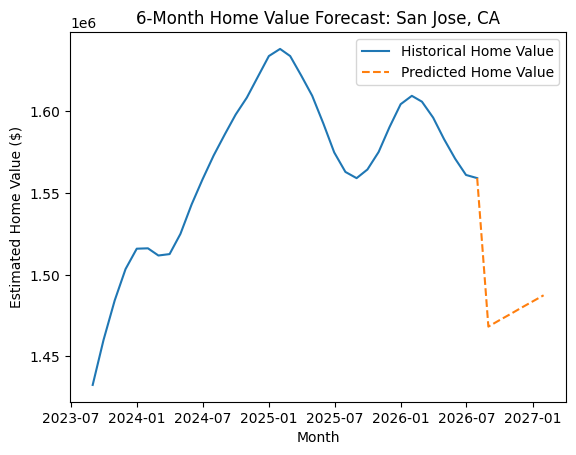

In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Metro_zhvi_uc.csv')

# Choose the metro area to forecast and only show recent years
METRO_NAME = 'San Jose, CA'
HISTORY_MONTHS_TO_SHOW = 36

# The dataset stores months as columns, so change the selected metro into
# the simple month-and-price format used by this forecasting code.
date_columns = [column for column in df.columns if len(column) == 10 and column[4] == '-']
metro_data = df[df['RegionName'] == METRO_NAME][date_columns].iloc[0]

df = pd.DataFrame({
    'date': pd.to_datetime(date_columns),
    'home_value': metro_data.values
}).dropna()
df['month'] = range(1, len(df) + 1)

# Features and target
X = df[['month']]
y = df['home_value']

# Train the model
model = LinearRegression()
model.fit(X, y)

# Predict for the next 6 months
future_months = pd.DataFrame({
    'month': range(max(df['month']) + 1, max(df['month']) + 7)
})
predictions = model.predict(future_months)

future_dates = pd.date_range(
    df['date'].max() + pd.offsets.MonthEnd(1),
    periods=6,
    freq='ME'
)

# Save the predicted prices
forecast = pd.DataFrame({
    'date': future_dates,
    'predicted_home_value': predictions.round(2)
})
forecast.to_csv('housing_price_forecast.csv', index=False)

# Plot results: show only recent years but still use all available data
recent_data = df.tail(HISTORY_MONTHS_TO_SHOW)
plot_dates = [recent_data['date'].iloc[-1], *future_dates]
plot_values = [recent_data['home_value'].iloc[-1], *predictions]

plt.plot(recent_data['date'], recent_data['home_value'], label='Historical Home Value')
plt.plot(plot_dates, plot_values, label='Predicted Home Value', linestyle='--')
plt.xlabel('Month')
plt.ylabel('Estimated Home Value ($)')
plt.title(f'6-Month Home Value Forecast: {METRO_NAME}')
plt.legend()
plt.savefig('housing_price_forecast.png')
plt.show()